In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import roc_auc_score

In [28]:
df = pd.read_csv("C:\Datasets\IDS_Dataset\DDoS-Friday-no-metadata.csv")

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Mohammad Saquib\AppData\Local\Temp\ipykernel_16448\1352318388.py:1: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv("C:\Datasets\IDS_Dataset\DDoS-Friday-no-metadata.csv")


In [29]:
df.head(5)

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,6,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,6,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,6,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,6,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


In [30]:
df.shape

(221264, 78)

In [31]:
df["Label"].value_counts()

Label
DDoS      128014
Benign     93250
Name: count, dtype: int64

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221264 entries, 0 to 221263
Data columns (total 78 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Protocol                  221264 non-null  int64  
 1   Flow Duration             221264 non-null  int64  
 2   Total Fwd Packets         221264 non-null  int64  
 3   Total Backward Packets    221264 non-null  int64  
 4   Fwd Packets Length Total  221264 non-null  int64  
 5   Bwd Packets Length Total  221264 non-null  int64  
 6   Fwd Packet Length Max     221264 non-null  int64  
 7   Fwd Packet Length Min     221264 non-null  int64  
 8   Fwd Packet Length Mean    221264 non-null  float64
 9   Fwd Packet Length Std     221264 non-null  float64
 10  Bwd Packet Length Max     221264 non-null  int64  
 11  Bwd Packet Length Min     221264 non-null  int64  
 12  Bwd Packet Length Mean    221264 non-null  float64
 13  Bwd Packet Length Std     221264 non-null  f

In [33]:
df['Protocol'].value_counts()

Protocol
6     190165
17     31045
0         54
Name: count, dtype: int64

In [ ]:
# Define and APPLY the drop to ensure parity with other models
cols_to_drop = [
    "Fwd Packets Length Total", "Bwd Packets Length Total", "Fwd Packet Length Max", 
    "Bwd Packet Length Max", "Fwd Packet Length Min", "Bwd Packet Length Min",
    "Fwd Packet Length Std", "Bwd Packet Length Std", "Flow IAT Std", "Flow IAT Total",
    "Fwd IAT Std", "Fwd IAT Max", "Fwd IAT Min", "Bwd IAT Total", "Bwd IAT Std", 
    "Bwd IAT Max", "Bwd IAT Min", "Fwd PSH Flags", "Bwd PSH Flags", "Fwd URG Flags", 
    "Bwd URG Flags", "Packet Length Variance", "PSH Flag Count", "URG Flag Count", 
    "CWE Flag Count", "ECE Flag Count", "Down/Up Ratio", "Avg Packet Size",
    "Avg Fwd Segment Size", "Avg Bwd Segment Size", "Fwd Avg Bytes/Bulk", 
    "Fwd Avg Packets/Bulk", "Fwd Avg Bulk Rate", "Bwd Avg Bytes/Bulk", 
    "Bwd Avg Packets/Bulk", "Bwd Avg Bulk Rate", "Subflow Bwd Bytes",
    "Init Fwd Win Bytes", "Init Bwd Win Bytes", "Fwd Act Data Packets", 
    "Fwd Seg Size Min", "Active Mean", "Active Std", "Active Max", "Active Min",
    "Idle Mean", "Idle Std", "Idle Max", "Idle Min"
]
df = df.drop(columns=cols_to_drop, axis=1, errors='ignore')
# Clean any infinity or NaN values resulting from scaling
df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

In [35]:
df.columns

Index(['Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Fwd Packets Length Total',
       'Bwd Packets Length Total', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Count', 'RST Fla

In [36]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])

In [37]:
df.shape

(221264, 78)

In [38]:
X = df.drop(columns=["Label"])
y = df["Label"]

In [39]:
print(df.isnull().sum())

Protocol                    0
Flow Duration               0
Total Fwd Packets           0
Total Backward Packets      0
Fwd Packets Length Total    0
                           ..
Idle Mean                   0
Idle Std                    0
Idle Max                    0
Idle Min                    0
Label                       0
Length: 78, dtype: int64


In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np

model = LogisticRegression(max_iter=1, warm_start=True, solver="saga", class_weight="balanced")

model.fit(X_train[:100], y_train[:100])

C:\Users\Mohammad Saquib\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1, warm_start=True)

In [52]:
y_pred = model.predict(X_test)
print(y_pred)

y_prob = model.predict_proba(X_test)
print(y_prob)

[1 0 1 ... 0 0 1]
[[0.         1.        ]
 [0.99513657 0.00486343]
 [0.09558871 0.90441129]
 ...
 [0.50022903 0.49977097]
 [0.58770717 0.41229283]
 [0.3600507  0.6399493 ]]


In [43]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy * 100, "%")

Accuracy: 77.2331819311685 %


In [44]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[11998  6717]
 [ 3358 22180]]


In [45]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.64      0.70     18715
           1       0.77      0.87      0.81     25538

    accuracy                           0.77     44253
   macro avg       0.77      0.75      0.76     44253
weighted avg       0.77      0.77      0.77     44253



In [46]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

all_labels = pd.concat([y_test, pd.Series(y_pred)])
le.fit(all_labels)

y_test_encoded = le.transform(y_test)
y_pred_encoded = le.transform(y_pred)
# Calculate ROC-AUC score with encoded labels
roc = roc_auc_score(y_test_encoded, y_pred_encoded)
print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.7547998532965192


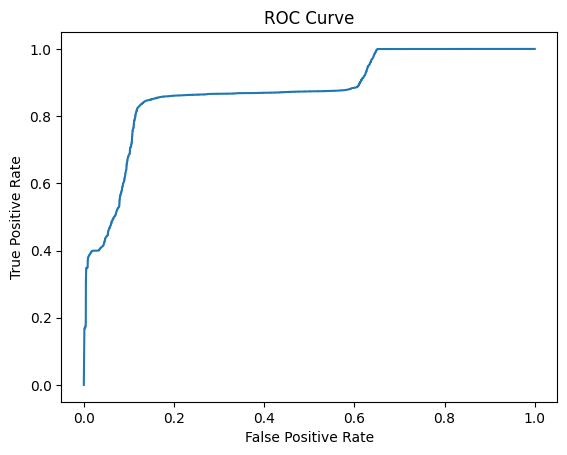

In [47]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test_encoded, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [48]:
y_train_pred = model.predict_proba(X_train)

In [49]:
y_test_pred = model.predict_proba(X_test)

In [50]:
from sklearn.metrics import accuracy_score

# Recalculate y_train_pred using the cleaned training data consistent with y_train_encoded
y_train_pred = model.predict_proba(X_train)

# y_train_pred and y_test_pred are already numerical from model.predict() (XGBClassifier)
# y_train_encoded and y_test_encoded are already numerical from previous LabelEncoder steps used for XGBoost

# Use encoded labels for accuracy calculation
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test_encoded, y_test_pred)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

ValueError: Classification metrics can't handle a mix of binary and continuous-multioutput targets

In [ ]:
from xgboost import XGBClassifier

In [ ]:
model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, eval_metric="logloss")

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

model.fit(X_train, y_train_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [ ]:
y_pred = model.predict_proba(X_test)
y_pred

array([1, 0, 1, ..., 0, 1, 1])

In [ ]:
accuracy = accuracy_score(y_test_encoded, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9999774026619664


In [ ]:
cm = confusion_matrix(y_test_encoded, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[18715     0]
 [    1 25537]]


In [ ]:
print(classification_report(y_test_encoded, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18715
           1       1.00      1.00      1.00     25538

    accuracy                           1.00     44253
   macro avg       1.00      1.00      1.00     44253
weighted avg       1.00      1.00      1.00     44253



In [ ]:
y_train_pred = model.predict_proba(X_train)

In [ ]:
y_train_pred = model.predict_proba(X_train)

In [ ]:
from sklearn.metrics import accuracy_score

# Recalculate y_train_pred using the cleaned training data consistent with y_train_encoded
y_train_pred = model.predict_proba(X_train)

# Use encoded labels for accuracy calculation
train_acc = accuracy_score(y_train_encoded, y_train_pred)
test_acc = accuracy_score(y_test_encoded, y_pred) # Assuming y_pred is the prediction for X_test

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.9999548050686116
Testing Accuracy: 0.9999774026619664


In [ ]:
from sklearn.linear_model import LogisticRegression

# We must use Logistic Regression for the weight-averaging FL strategy
model = LogisticRegression(max_iter=1000, class_weight="balanced")

# Train the base model
model.fit(X_train, y_train)

print("Base Logistic Regression model trained and ready for Federated Learning.")

Base Logistic Regression model trained and ready for Federated Learning.


C:\Users\Mohammad Saquib\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

# Train (just stores data)
knn.fit(X_train, y_train)

# Predict
y_pred = knn.predict_proba(X_test)

# Accuracy
print("KNN Accuracy:", accuracy_score(y_test, y_pred))

KNN Accuracy: 0.9972657220979368


In [ ]:
# from sklearn.svm import SVC

# svm = SVC(kernel='linear')

# svm.fit(X_train, y_train)

# y_pred = svm.predict(X_test)

# # Accuracy
# print("SVM Accuracy:", accuracy_score(y_test, y_pred))

In [ ]:
import flwr as fl
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

# 1. Define the Flower client
class IDSClient(fl.client.NumPyClient):
    def __init__(self, X_train, y_train, X_test, y_test):
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        
        # Initialize your model from the notebook
        self.model = LogisticRegression(
            max_iter=1,      # We train 1 iteration per FL round
            warm_start=True, # Important! Keeps weights from previous round
            class_weight="balanced"
        )
        
        # Initial dummy fit to set coordinate shapes
        self.model.fit(self.X_train[:10], self.y_train[:10])

    def get_parameters(self, config):
        # Send weights and intercept to the server
        return [self.model.coef_, self.model.intercept_]

    def set_parameters(self, parameters):
        # Update local model with global weights from server
        self.model.coef_ = parameters[0]
        self.model.intercept_ = parameters[1]

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        self.model.fit(self.X_train, self.y_train)
        return self.get_parameters(config={}), len(self.X_train), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        loss = log_loss(self.y_test, self.model.predict_proba(self.X_test))
        accuracy = self.model.score(self.X_test, self.y_test)
        return loss, len(self.X_test), {"accuracy": accuracy}

In [ ]:
# Partition the data into 3 clients (simulating 3 different locations)
def partition_data(X, y, num_clients=3):
    partitions = []
    chunk_size = len(X) // num_clients
    for i in range(num_clients):
        X_chunk = X[i*chunk_size : (i+1)*chunk_size]
        y_chunk = y[i*chunk_size : (i+1)*chunk_size]
        partitions.append((X_chunk, y_chunk))
    return partitions

# To run this:
# 1. Start the Server
# fl.server.start_server(config=fl.server.ServerConfig(num_rounds=5))

# 2. Start Clients (in separate terminals or a loop)
# fl.client.start_numpy_client(server_address="127.0.0.1:8080", client=IDSClient(...))

In [ ]:
import pandas as pd
import numpy as np
import flwr as fl
import ray
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss

# --- STEP 1: PREPROCESSING (From your notebook) ---
def load_and_preprocess():
    # Use the path from your uploaded notebook
    df = pd.read_csv(r"C:\Datasets\IDS_Dataset\DDoS-Friday-no-metadata.csv")
    
    # Drop columns as you did in your notebook
    cols_to_drop = ["Fwd Packets Length Total", "Bwd Packets Length Total", "Fwd Packet Length Max", 
                    "Bwd Packet Length Max", "Fwd Packet Length Min", "Bwd Packet Length Min",
                    "Fwd Packet Length Std", "Bwd Packet Length Std", "Flow IAT Std", "Flow IAT Total"]
    df = df.drop(columns=cols_to_drop, axis=1, errors='ignore')
    
    # Simple encoding for Label
    df['Label'] = df['Label'].map({'Benign': 0, 'DDoS': 1})
    df = df.dropna()
    
    X = df.drop(columns=["Label"]).values
    y = df["Label"].values
    
    # Split into a global test set and training data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    return X_train, X_test, y_train, y_test

# --- STEP 2: DEFINE THE FL CLIENT ---
class IDSClient(fl.client.NumPyClient):
    def __init__(self, x_train, y_train, x_test, y_test):
        self.x_train, self.y_train = x_train, y_train
        self.x_test, self.y_test = x_test, y_test
        self.model = LogisticRegression(max_iter=1, warm_start=True, class_weight="balanced")
        # Dummy fit to initialize parameters
        self.model.fit(self.x_train[:10], self.y_train[:10])

    def get_parameters(self, config):
        return [self.model.coef_, self.model.intercept_]

    def set_parameters(self, parameters):
        self.model.coef_ = parameters[0]
        self.model.intercept_ = parameters[1]

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        self.model.fit(self.x_train, self.y_train)
        return self.get_parameters(config={}), len(self.x_train), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        loss = log_loss(self.y_test, self.model.predict_proba(self.x_test), labels=[0, 1])
        accuracy = self.model.score(self.x_test, self.y_test)
        return loss, len(self.x_test), {"accuracy": accuracy}

# --- STEP 3: RUN THE SIMULATION ---
X_train, X_test, y_train, y_test = load_and_preprocess()

# Split training data for 3 virtual clients
def client_fn(cid: str):
    # Partitioning the 80% training data into 3 parts
    n = len(X_train) // 3
    idx = int(cid)
    x_c, y_c = X_train[idx*n : (idx+1)*n], y_train[idx*n : (idx+1)*n]
    return IDSClient(x_c, y_c, X_test, y_test)

strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0,          # Sample 100% of available clients for training
    fraction_evaluate=1.0,     # Sample 100% of available clients for evaluation
    min_available_clients=3,   # Wait until all 3 clients are connected
)

# Start Simulation with specific resource allocation to prevent Ray crashes
fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=3,
    config=fl.server.ServerConfig(num_rounds=5),
    strategy=strategy,
    ray_init_args={"num_cpus": 2} # Helps stability on Windows/Laptops
)

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=5, no round_timeout
2026-04-19 17:24:31,021	INFO worker.py:2012 -- Started a local Ray instance.
C:\Users\Mohammad Saquib\AppData\Roaming\Python\Python312\site-packages\ray\_private\worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
INFO :      Flower VCE: Ray initialized with resources: {'object_store_memory': 

History (loss, distributed):
	round 1: 2.3929374657027624
	round 2: 0.5430296643479595
	round 3: 0.4968739983709455
	round 4: 0.486418100845023
	round 5: 0.44970107126808834

(pid=gcs_server) [2026-04-19 17:24:58,709 E 23504 27744] (gcs_server.exe) gcs_server.cc:302: Failed to establish connection to the event+metrics exporter agent. Events and metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
(raylet) [2026-04-19 17:25:03,012 E 13856 1016] (raylet.exe) main.cc:975: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14


In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score

# --- STEP 1: Generate 100 Samples in the Notebook ---
n_features = 29 
columns = [
    'Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Fwd Packet Length Mean', 'Bwd Packet Length Mean', 'Flow Bytes/s', 
    'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Max', 'Flow IAT Min', 
    'Fwd IAT Total', 'Fwd IAT Mean', 'Bwd IAT Mean', 'Fwd Header Length',
    'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 
    'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 
    'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'ACK Flag Count', 
    'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets'
]

X_synth, y_true = make_classification(n_samples=100, n_features=n_features, random_state=42)
test_df = pd.DataFrame(X_synth, columns=X.columns)
test_df = pd.DataFrame(X_synth, columns=columns)

# --- STEP 2: Use your 'model' object (LogisticRegression) from your previous cells ---
# We assume 'model' is already trained from your notebook history.

# 1. Inspect the Weights (Coefficients)
weights = model.coef_
intercept = model.intercept_

print("--- FEDERATED PARAMETERS ---")
print(f"Total Weight Parameters: {weights.size}")
print(f"Global Bias (Intercept): {intercept[0]:.4f}")
print(f"Top 3 Feature Weights: {np.sort(weights[0])[-3:]}")
print("-" * 40)

# 2. Run Predictions on the 100 samples
y_pred = model.predict(test_df)

# 3. Expecting Output: Class Labels and Accuracy
print("--- PREDICTION OUTPUT ---")
print(f"First 10 Predictions (0=Benign, 1=DDoS): {y_pred[:10]}")
print(f"Test Accuracy on Synthetic Samples: {accuracy_score(y_true, y_pred) * 100:.2f}%")

ValueError: Shape of passed values is (100, 29), indices imply (100, 77)